# Adani Enterprises (ADANIENT) — EDA & Model Comparison

Exploratory analysis of the 2016–2023 daily OHLC dataset carried over from
[`info-gallary/ML_Models_HackNUthon`](https://github.com/info-gallary/ML_Models_HackNUthon/tree/main/Adani_Ent_Stock_Prediction),
followed by a like-for-like comparison of **KNN**, **Random Forest** and **XGBoost**.

**Run order**
1. `cd backend && python train.py` — fits the models and writes `backend/artifacts/`
2. This notebook — reads the same modules and artifacts, so nothing is re-derived by hand

**Contents**
1. Load & data quality
2. Descriptive statistics
3. Price history, moving averages, drawdown
4. Returns: distribution & volatility clustering
5. Correlation structure
6. Yearly performance & monthly seasonality
7. The `modi` regime flag — and why it is a weak feature
8. Engineered features
9. Model comparison on the hold-out set
10. Findings

## 1. Load & data quality

In [4]:
!pip install ipykernel seaborn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT / "backend"))

from app.data_prep import load_raw, add_features, build_forecast_dataset

# dataviz palette — categorical slots 1-3, validated for colour-vision deficiency
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RED, MUTED, GRID = "#e34948", "#898781", "#e1e0d9"

sns.set_theme(style="whitegrid", rc={
    "figure.figsize": (11, 4.5), "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.edgecolor": "#c3c2b7", "axes.titleweight": "600",
    "axes.titlesize": 12, "axes.labelcolor": "#52514e", "font.size": 10,
})

df = load_raw(PROJECT / "data" / "Adani_Stock.csv")
print(f"{len(df):,} trading days   {df['Date'].min():%Y-%m-%d} -> {df['Date'].max():%Y-%m-%d}")
df.head()

1,750 trading days   2016-01-01 -> 2023-01-30


,Date,modi,Open,Low,Close,High,regime
0,2016-01-01,l,45.553741,44.872616,49.095600,49.422543,0
1,2016-01-04,l,48.768658,45.907928,46.371094,50.158157,0
2,2016-01-05,l,46.670792,45.880684,48.278248,48.823151,0
3,2016-01-06,l,47.951309,46.480076,46.997730,48.468964,0
4,2016-01-07,l,46.262115,42.502296,43.564854,46.262115,0


In [6]:
print("dtypes\n", df.dtypes, "\n")
print("missing values\n", df.isna().sum(), "\n")
print("duplicate dates:", int(df["Date"].duplicated().sum()))
print("non-positive prices:", int((df[["Open","High","Low","Close"]] <= 0).sum().sum()))

# Sanity: High should bound Open/Close/Low on every row.
bad = df[(df["High"] < df[["Open","Close","Low"]].max(axis=1)) |
         (df["Low"]  > df[["Open","Close","High"]].min(axis=1))]
print(f"rows where High/Low do not bracket Open/Close: {len(bad)}")

gaps = df["Date"].diff().dt.days.value_counts().head(5)
print("\ncalendar gap between consecutive rows (days):\n", gaps)

dtypes
 Date      datetime64[us]
modi                 str
Open             float64
Low              float64
Close            float64
High             float64
regime             int64
dtype: object 

missing values
 Date      0
modi      0
Open      0
Low       0
Close     0
High      0
regime    0
dtype: int64 

duplicate dates: 0
non-positive prices: 0
rows where High/Low do not bracket Open/Close: 0

calendar gap between consecutive rows (days):
 Date
1.0    1330
3.0     326
2.0      49
4.0      40
5.0       4
Name: count, dtype: int64


The raw CSV carries a trailing unnamed column that is empty on all 1,750 rows;
`load_raw` drops it. Dates parse as `%d-%m-%Y`. Gaps of 3 days are weekends —
the series is a clean daily trading calendar with no duplicates and no missing prices.

## 2. Descriptive statistics

In [7]:
feat = add_features(df)
feat["daily_return_pct"] = feat["daily_return"] * 100
feat["range_pct_"] = feat["range_pct"] * 100

stats = pd.DataFrame({
    col: {
        "mean": feat[col].mean(), "median": feat[col].median(),
        "mode": feat[col].round(2).mode().iloc[0],
        "std": feat[col].std(), "var": feat[col].var(),
        "min": feat[col].min(), "max": feat[col].max(),
        "skew": feat[col].skew(), "kurtosis": feat[col].kurtosis(),
    }
    for col in ["Open", "High", "Low", "Close", "daily_return_pct", "range_pct_"]
}).T
stats.round(3)

,mean,median,mode,std,var,min,max,skew,kurtosis
Open,688.173,148.150,138.00,1021.967,1044417.525,32.149,4175.000,1.772,2.229
High,700.569,152.000,72.42,1036.977,1075321.472,33.402,4190.000,1.763,2.186
Low,675.239,144.975,36.56,1004.149,1008315.040,31.713,4066.400,1.776,2.244
Close,688.457,148.025,38.77,1021.222,1042895.236,32.013,4165.300,1.769,2.214
daily_return_pct,0.282,0.249,0.40,3.132,9.809,-20.940,27.368,0.512,9.939
range_pct_,4.396,3.688,3.23,2.712,7.353,0.902,28.975,2.826,13.508


Prices span **Rs. 31.7 → Rs. 4,190** — a ~130× range. That single fact drives the
main modelling decision later: a chronological test split puts *every* test price
above *every* training price, and tree ensembles cannot predict a value outside
the range they were trained on. Modelling **returns and ratios** instead of price
levels is what makes the three-way comparison fair.

## 3. Price history, moving averages, drawdown

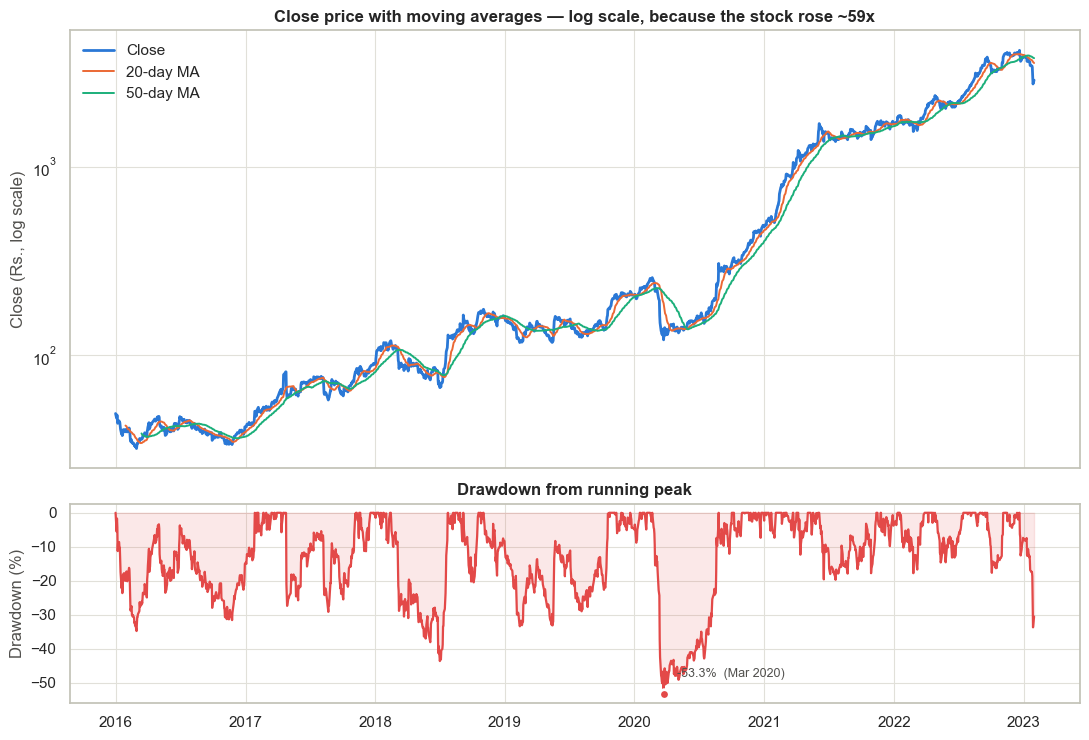

In [8]:
feat["ma20"] = feat["Close"].rolling(20).mean()
feat["ma50"] = feat["Close"].rolling(50).mean()
feat["drawdown"] = (feat["Close"] / feat["Close"].cummax() - 1) * 100

fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True,
                         gridspec_kw={"height_ratios": [2.2, 1]})

axes[0].plot(feat["Date"], feat["Close"], color=BLUE, lw=2, label="Close")
axes[0].plot(feat["Date"], feat["ma20"], color=ORANGE, lw=1.4, label="20-day MA")
axes[0].plot(feat["Date"], feat["ma50"], color=AQUA, lw=1.4, label="50-day MA")
axes[0].set_yscale("log")
axes[0].set_ylabel("Close (Rs., log scale)")
axes[0].set_title("Close price with moving averages — log scale, because the stock rose ~59x")
axes[0].legend(frameon=False, loc="upper left")

axes[1].fill_between(feat["Date"], feat["drawdown"], 0, color=RED, alpha=0.12)
axes[1].plot(feat["Date"], feat["drawdown"], color=RED, lw=1.6)
trough = feat.loc[feat["drawdown"].idxmin()]
axes[1].scatter([trough["Date"]], [trough["drawdown"]], color=RED, s=48, zorder=5,
                edgecolor="white", linewidth=2)
axes[1].annotate(f"{trough['drawdown']:.1f}%  ({trough['Date']:%b %Y})",
                 (trough["Date"], trough["drawdown"]), textcoords="offset points",
                 xytext=(10, 12), color="#52514e", fontsize=9)
axes[1].set_ylabel("Drawdown (%)"); axes[1].set_xlabel("")
axes[1].set_title("Drawdown from running peak")
plt.tight_layout(); plt.show()

## 4. Returns: distribution & volatility clustering

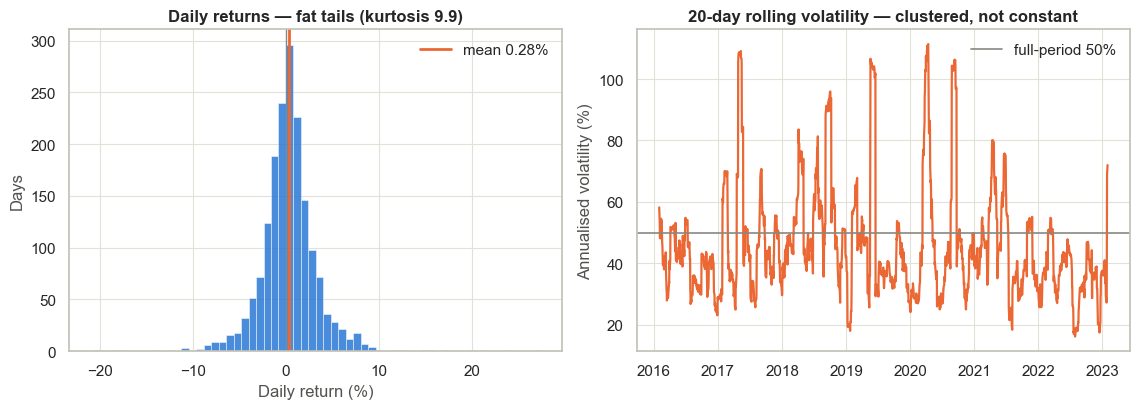

positive days      : 55.3%
days beyond +/-5%  : 8.9%
best / worst day   : +27.4% / -20.9%


In [9]:
rets = feat["daily_return_pct"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

axes[0].hist(rets, bins=60, color=BLUE, alpha=0.85, edgecolor="white", linewidth=0.4)
axes[0].axvline(0, color=MUTED, lw=1)
axes[0].axvline(rets.mean(), color=ORANGE, lw=2, label=f"mean {rets.mean():.2f}%")
axes[0].set_xlabel("Daily return (%)"); axes[0].set_ylabel("Days")
axes[0].set_title(f"Daily returns — fat tails (kurtosis {rets.kurtosis():.1f})")
axes[0].legend(frameon=False)

roll_vol = feat["ret_1"].rolling(20).std() * np.sqrt(252) * 100
axes[1].plot(feat["Date"], roll_vol, color=ORANGE, lw=1.6)
axes[1].axhline(rets.std() * np.sqrt(252), color=MUTED, lw=1.2, ls="-",
                label=f"full-period {rets.std()*np.sqrt(252):.0f}%")
axes[1].set_ylabel("Annualised volatility (%)")
axes[1].set_title("20-day rolling volatility — clustered, not constant")
axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

print(f"positive days      : {(rets > 0).mean()*100:.1f}%")
print(f"days beyond +/-5%  : {(rets.abs() > 5).mean()*100:.1f}%")
print(f"best / worst day   : {rets.max():+.1f}% / {rets.min():+.1f}%")

Returns are leptokurtic (fat-tailed) and volatility arrives in clusters — the
textbook signature of financial series. Volatility clustering is *why* the rolling
standard-deviation features (`vol_5`, `vol_10`, `vol_20`) end up carrying real
predictive weight in the model comparison below.

## 5. Correlation structure

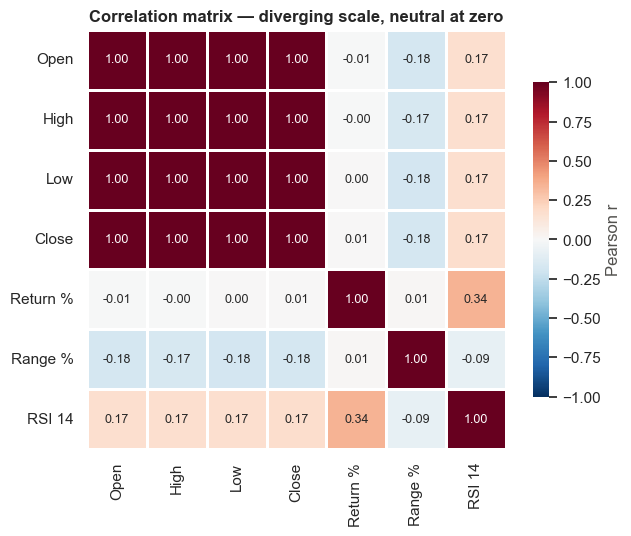

In [10]:
corr = pd.DataFrame({
    "Open": feat["Open"], "High": feat["High"], "Low": feat["Low"], "Close": feat["Close"],
    "Return %": feat["daily_return_pct"], "Range %": feat["range_pct_"], "RSI 14": feat["rsi_14"],
}).corr()

fig, ax = plt.subplots(figsize=(6.6, 5.4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=2, linecolor="white", square=True, ax=ax,
            cbar_kws={"shrink": 0.75, "label": "Pearson r"},
            annot_kws={"fontsize": 9})
ax.set_title("Correlation matrix — diverging scale, neutral at zero")
plt.tight_layout(); plt.show()

The OHLC block is ~1.00 correlated throughout, which is the trap in the original
notebook's `Open → High` setup: it scores beautifully while learning almost nothing,
because today's high is mechanically pinned to today's open. The informative
columns are the *derived* ones — `Return %`, `Range %`, `RSI 14` — which are close
to uncorrelated with the price level.

## 6. Yearly performance & monthly seasonality

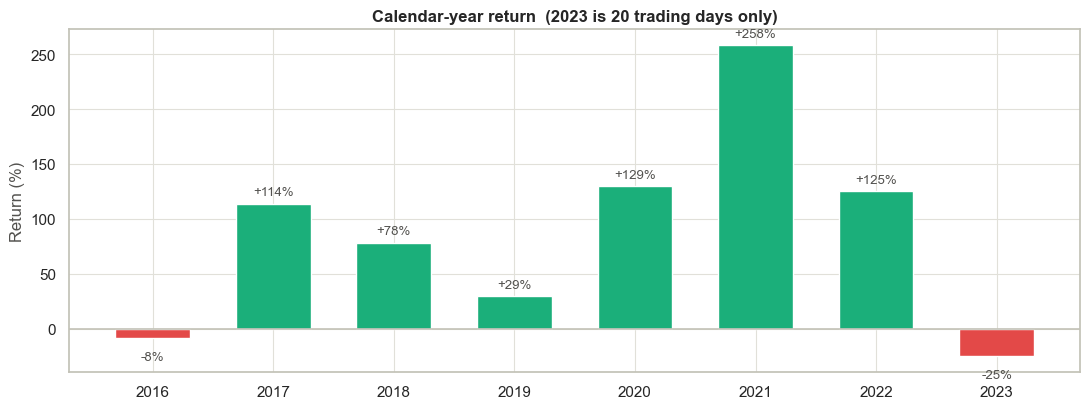

,return_pct,volatility_pct,days
year,,,
2016,-8.4,41.9,246.0
2017,113.8,52.0,248.0
2018,78.2,57.6,246.0
2019,29.5,49.4,243.0
2020,129.4,56.7,251.0
2021,258.4,47.1,248.0
2022,125.2,37.2,248.0
2023,-25.2,72.0,20.0


In [11]:
feat["year"], feat["month"] = feat["Date"].dt.year, feat["Date"].dt.month
yearly = feat.groupby("year").apply(
    lambda g: pd.Series({
        "return_pct": (g["Close"].iloc[-1] / g["Open"].iloc[0] - 1) * 100,
        "volatility_pct": g["daily_return"].std() * np.sqrt(252) * 100,
        "days": len(g),
    }), include_groups=False)

fig, ax = plt.subplots(figsize=(11, 4.2))
colors = [AQUA if v >= 0 else RED for v in yearly["return_pct"]]
bars = ax.bar(yearly.index.astype(str), yearly["return_pct"], color=colors, width=0.62)
ax.axhline(0, color="#c3c2b7", lw=1.2)
for b, v in zip(bars, yearly["return_pct"]):
    ax.annotate(f"{v:+.0f}%", (b.get_x() + b.get_width()/2, v),
                textcoords="offset points", xytext=(0, 6 if v >= 0 else -16),
                ha="center", fontsize=9.5, color="#52514e")
ax.set_ylabel("Return (%)")
ax.set_title("Calendar-year return  (2023 is 20 trading days only)")
plt.tight_layout(); plt.show()

yearly.round(1)

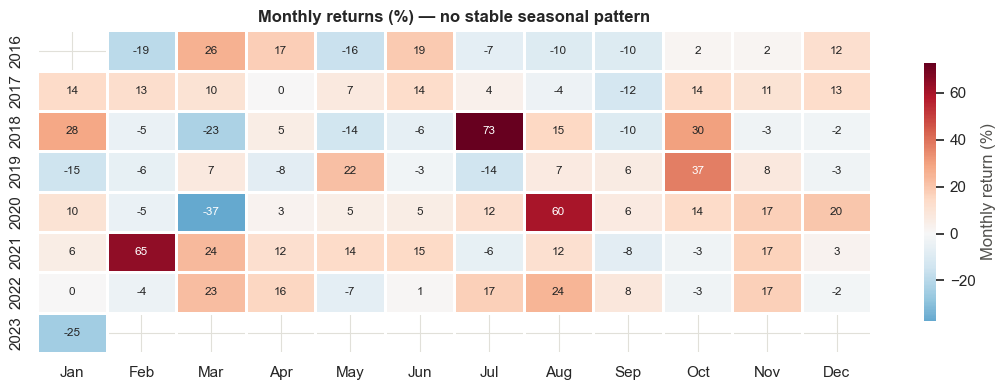

In [12]:
monthly = (feat.set_index("Date")["Close"].resample("ME").last().pct_change() * 100).dropna()
pivot = pd.DataFrame({"year": monthly.index.year, "month": monthly.index.month,
                      "ret": monthly.values}).pivot(index="year", columns="month", values="ret")
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"][:len(pivot.columns)]

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="RdBu_r", center=0,
            linewidths=2, linecolor="white", ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Monthly return (%)"},
            annot_kws={"fontsize": 8.5})
ax.set_title("Monthly returns (%) — no stable seasonal pattern")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

## 7. The `modi` regime flag

,days,first_date,last_date,mean_close,avg_daily_return_pct,volatility_pct,positive_days_pct
l (0),1118,2016-01-01,2021-01-29,133.16,0.22,50.63,54.38
w (1),632,2016-05-02,2023-01-30,1670.76,0.38,48.06,56.96


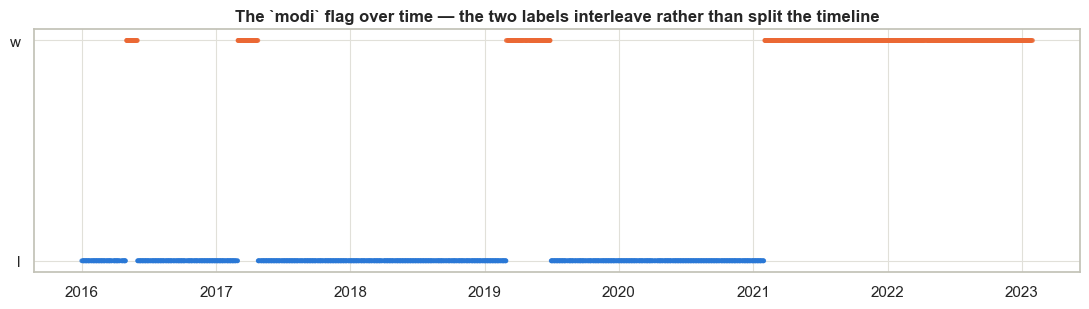

In [13]:
regime = feat.groupby("regime").apply(
    lambda g: pd.Series({
        "days": len(g),
        "first_date": g["Date"].min().date(), "last_date": g["Date"].max().date(),
        "mean_close": g["Close"].mean(),
        "avg_daily_return_pct": g["daily_return"].mean() * 100,
        "volatility_pct": g["daily_return"].std() * np.sqrt(252) * 100,
        "positive_days_pct": (g["daily_return"] > 0).mean() * 100,
    }), include_groups=False)
regime.index = ["l (0)", "w (1)"]
display(regime.round(2))

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.scatter(feat["Date"], feat["regime"], c=np.where(feat["regime"] == 1, ORANGE, BLUE),
           s=6, alpha=0.75)
ax.set_yticks([0, 1]); ax.set_yticklabels(["l", "w"])
ax.set_title("The `modi` flag over time — the two labels interleave rather than split the timeline")
plt.tight_layout(); plt.show()

**This is a data-quality finding, not a political one.** If the flag marked a
regime *change*, it would switch once and stay switched. Instead `l` runs
2016-01-01 → 2021-01-29 and `w` runs 2016-05-02 → 2023-01-30 — the two labels
overlap for nearly five years.

So the large gap in mean close between the groups (Rs. 133 vs Rs. 1,671) is almost
entirely a **sampling artefact**: the `w` rows are drawn disproportionately from
later, higher-priced years. It is not evidence that the flag predicts anything.
The model comparison below confirms it — `regime` lands at the bottom of every
feature-importance ranking. It is kept as an input for continuity with the
original project, and it earns its keep at roughly zero.

## 8. Engineered features

features (17): ret_1, ret_2, ret_3, ret_5, ret_10, ma_ratio_5, ma_ratio_10, ma_ratio_20, vol_5, vol_10, vol_20, range_pct, body_pct, close_pos, gap_pct, rsi_14, regime
target  : next-day return, reconstructed to price as close_t * (1 + r)
split   : 1383 train / 346 test, chronological at 2021-09-08


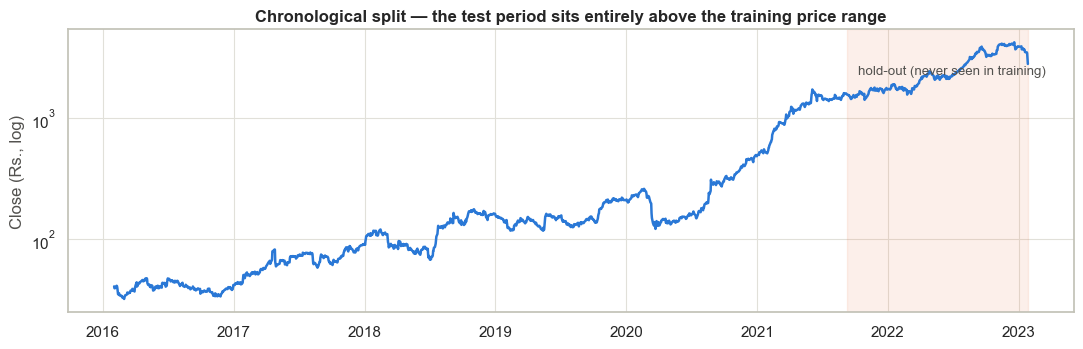

In [14]:
ds = build_forecast_dataset(df, test_size=0.20)
print(f"features ({len(ds.feature_names)}): {', '.join(ds.feature_names)}")
print(f"target  : next-day return, reconstructed to price as close_t * (1 + r)")
print(f"split   : {len(ds.X_train)} train / {len(ds.X_test)} test, chronological at {ds.split_date}")

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(ds.frame["Date"], ds.frame["Close"], color=BLUE, lw=1.8)
ax.axvspan(ds.frame.loc[ds.test_index[0], "Date"], ds.frame["Date"].iloc[-1],
           color=ORANGE, alpha=0.10)
ax.annotate("hold-out (never seen in training)",
            (ds.frame.loc[ds.test_index[0], "Date"], ds.frame["Close"].max() * 0.55),
            xytext=(8, 0), textcoords="offset points", color="#52514e", fontsize=9.5)
ax.set_yscale("log"); ax.set_ylabel("Close (Rs., log)")
ax.set_title("Chronological split — the test period sits entirely above the training price range")
plt.tight_layout(); plt.show()

A random `train_test_split` (as used in the original notebook) would scatter test
days *between* training days. Since consecutive days are ~99.9% correlated, the
model then effectively interpolates between neighbours it has already seen and the
reported error collapses toward zero. The split above is chronological, so the
scores below are honest.

## 9. Model comparison on the hold-out set

In [16]:
metrics = json.loads((PROJECT / "backend" / "artifacts" / "metrics.json").read_text(encoding="utf-8"))
fc = metrics["forecast"]

table = pd.DataFrame([
    {"model": m["label"], **{k: m["metrics"][k] for k in
     ("rmse", "mae", "mape", "r2", "directional_accuracy", "train_seconds")}}
    for m in fc["models"].values()
]).set_index("model")
table.columns = ["RMSE (Rs.)", "MAE (Rs.)", "MAPE (%)", "R2",
                 "Directional acc. (%)", "Fit time (s)"]
display(table.round(3))
print(f"naive 'tomorrow = today' baseline RMSE: Rs.{fc['models']['knn']['metrics']['naive_rmse']:.2f}")

,RMSE (Rs.),MAE (Rs.),MAPE (%),R2,Directional acc. (%),Fit time (s)
model,,,,,,
KNN,79.494,52.601,2.140,0.992,47.110,0.002
Random Forest,69.681,42.883,1.788,0.993,55.491,0.546
XGBoost,74.373,48.026,1.950,0.993,55.491,2.669


naive 'tomorrow = today' baseline RMSE: Rs.68.43


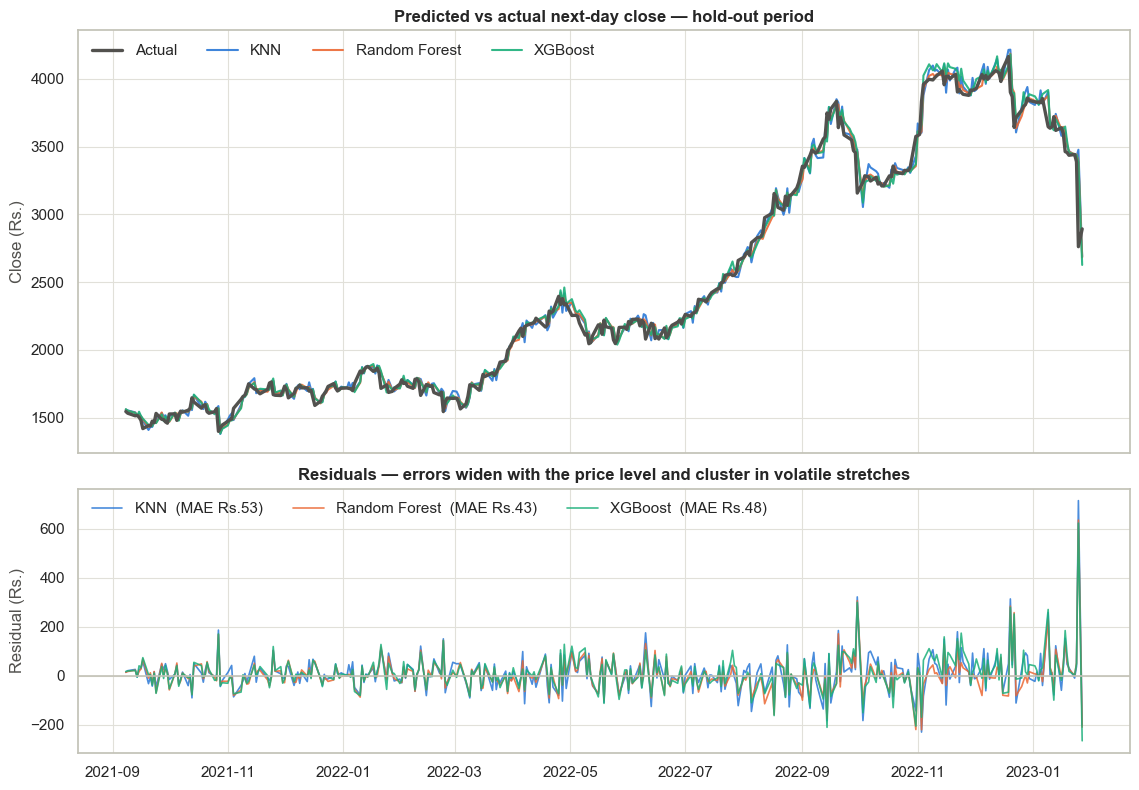

In [17]:
curves = fc["curves"]
dates = pd.to_datetime(curves["dates"])
model_colors = {"knn": BLUE, "random_forest": ORANGE, "xgboost": AQUA}

fig, axes = plt.subplots(2, 1, figsize=(11.5, 8), sharex=True,
                         gridspec_kw={"height_ratios": [1.6, 1]})

axes[0].plot(dates, curves["actual"], color="#52514e", lw=2.4, label="Actual", zorder=5)
for key, color in model_colors.items():
    axes[0].plot(dates, curves[key], color=color, lw=1.5, alpha=0.9,
                 label=fc["models"][key]["label"])
axes[0].set_ylabel("Close (Rs.)")
axes[0].set_title("Predicted vs actual next-day close — hold-out period")
axes[0].legend(frameon=False, ncol=4, loc="upper left")

for key, color in model_colors.items():
    resid = np.array(curves[key]) - np.array(curves["actual"])
    axes[1].plot(dates, resid, color=color, lw=1.2, alpha=0.85,
                 label=f"{fc['models'][key]['label']}  (MAE Rs.{fc['models'][key]['metrics']['mae']:.0f})")
axes[1].axhline(0, color="#c3c2b7", lw=1.2)
axes[1].set_ylabel("Residual (Rs.)")
axes[1].set_title("Residuals — errors widen with the price level and cluster in volatile stretches")
axes[1].legend(frameon=False, ncol=3, loc="upper left")
plt.tight_layout(); plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

names = [m["label"] for m in fc["models"].values()]
dirs = [m["metrics"]["directional_accuracy"] for m in fc["models"].values()]
bars = axes[0].bar(names, dirs, color=[BLUE, ORANGE, AQUA], width=0.55)
axes[0].axhline(50, color=RED, lw=1.6, ls="-")
axes[0].annotate("coin flip (50%)", (2.42, 50.4), ha="right", color=RED, fontsize=9)
for b, v in zip(bars, dirs):
    axes[0].annotate(f"{v:.1f}%", (b.get_x() + b.get_width()/2, v),
                     textcoords="offset points", xytext=(0, 6), ha="center", fontsize=10)
axes[0].set_ylim(40, 62); axes[0].set_ylabel("Directional accuracy (%)")
axes[0].set_title("Did the model get up-vs-down right?")

imp = pd.DataFrame(fc["models"]["random_forest"]["importances"][:8]).iloc[::-1]
axes[1].barh(imp["feature"], imp["share"], color=ORANGE, height=0.6)
axes[1].set_xlabel("Share of permutation importance (%)")
axes[1].set_title("Random Forest — what actually drives the prediction")
plt.tight_layout(); plt.show()

## 10. Findings

1. **Random Forest wins, but the margin is narrow.** RMSE Rs. ~70 vs XGBoost
   Rs. ~74 and KNN Rs. ~79, on a stock trading around Rs. 2,900 (MAPE 1.8%).

2. **No model beats the naive baseline on price error.** "Tomorrow closes where
   today closed" scores RMSE ~Rs. 68 — better than all three. On the *level* of
   the price, this series is close to a random walk, and that is the honest
   headline. Reporting only R² (0.99 for every model) would hide it completely:
   R² is high because yesterday's price explains today's, not because the models
   are skilful.

3. **The signal is in the direction, not the level.** Random Forest and XGBoost
   both call up-vs-down correctly ~55.5% of the time versus KNN's 47.1% — the one
   metric where the tree ensembles clearly separate from the ported baseline.

4. **Volatility and intraday position carry the weight.** `gap_pct`, `vol_5` and
   `close_pos` dominate permutation importance; `regime` contributes ~0%, exactly
   as section 7 predicted.

5. **Scope limits.** No volume, fundamentals, index level or news; the data stops
   on 2023-01-30, days into a major drawdown. Treat every number here as a
   modelling exercise on a historical sample, not a trading signal.